<span style='font-family:Georgia'>
<div align="center">
   <h1> ME630 Compuational Fluid dynamics (ME 630) </h1>
       <h1> Prof. Santanu De</h1>
       
<h1> Assignment (2) - Problem 3   </h1>

<h1>  Tarek Issa (252050605) </h1>
</div>
________________________________________________________________________________________________________________


In [130]:
%%html 
<div id="tnr-styler-root"></div> 
<style> 
    /* 1. Target the Markdown cells that come AFTER this styling block */ 
    .cell:has(#tnr-styler-root) ~ .cell .rendered_html, 
    .jp-Cell:has(#tnr-styler-root) ~ .jp-Cell .jp-MarkdownOutput, 
    .jp-Cell:has(#tnr-styler-root) ~ .jp-Cell .text_cell_render { 
        font-family: "Times New Roman", Times, serif !important; 
    } 
 
    /* 2. Target the MathJax/LaTeX equations inside those subsequent Markdown cells */ 
    .cell:has(#tnr-styler-root) ~ .cell .MathJax_Display,  
    .cell:has(#tnr-styler-root) ~ .cell .MathJax,  
    .cell:has(#tnr-styler-root) ~ .cell .mjx-chtml, 
    .jp-Cell:has(#tnr-styler-root) ~ .jp-Cell .MathJax, 
    .jp-Cell:has(#tnr-styler-root) ~ .jp-Cell .mjx-chtml { 
        font-family: "Times New Roman", Times, serif !important; 
    } 
 
    /* 3. Force-hide this specific cell's input code container and prompt index */ 
    .cell:has(#tnr-styler-root) .input, 
    .cell:has(#tnr-styler-root) .prompt, 
    .jp-Cell:has(#tnr-styler-root) .jp-Cell-inputWrapper { 
        display: none !important; 
    } 
</style> 
<script> 
    // Robust fall-back layer: uses an active polling cycle to vaporize the container  
    // in sandboxed frontends (like VS Code/JupyterLab) that process layouts lazily. 
    (function hideContainer() { 
        const root = document.getElementById('tnr-styler-root'); 
        if (!root) return; 
        const container = root.closest('.jp-Cell') || root.closest('.cell'); 
        if (container) { 
            const inputArea = container.querySelector('.jp-Cell-inputWrapper') || container.querySelector('.input'); 
            if (inputArea) { inputArea.style.display = 'none'; } 
        } else { 
            setTimeout(hideContainer, 50); 
        } 
    })(); 
</script> 

# Convective quench of a solid cylinder (1D, cylindrical coordinates) 

A long solid cylinder of radius $R$, initially at uniform temperature $T_i$, is suddenly exposed at $t = 0$ to a convective environment $(h, T_\infty)$ over its entire curved surface (Fig. 3). Find $T(r, t)$.

$$
\frac{\partial T}{\partial t} = \alpha \left[ \frac{\partial^2 T}{\partial r^2} + \frac{1}{r} \frac{\partial T}{\partial r} \right], \quad 0 \leq r \leq R,
$$

$$
\left. \frac{\partial T}{\partial r} \right|_{r=0} = 0, \quad -k \left. \frac{\partial T}{\partial r} \right|_{r=R} = h(T(R,t) - T_\infty).
$$

**Data:** $R = 0.02$ m, $\alpha = 1.0 \times 10^{-5}$ m$^2$/s, $k = 20$ W/(m$\cdot$K), $h = 200$ W/(m$^2$$\cdot$K) (so $Bi = hR/k = 0.2$), $T_i = 300^\circ$C, $T_\infty = 25^\circ$C.

**Analytical solution (series;** $\theta = T - T_\infty$, $\theta_i = T_i - T_\infty$, $Fo = \alpha t/R^2$**):**

$$
\frac{\theta(r,t)}{\theta_i} = \sum_{n=1}^{\infty} C_n e^{-\lambda_n^2 Fo} J_0\left(\lambda_n \frac{r}{R}\right), \quad C_n = \frac{2}{\lambda_n} \frac{J_1(\lambda_n)}{J_0^2(\lambda_n) + J_1^2(\lambda_n)},
$$

where $\lambda_n$ are the positive roots of $\lambda_n J_1(\lambda_n) = Bi \, J_0(\lambda_n)$.

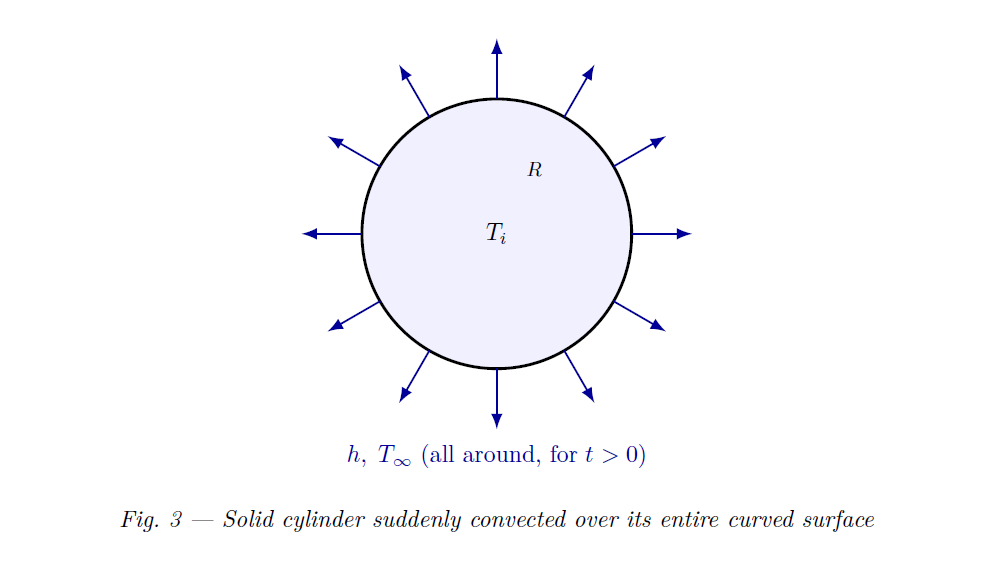

## Tasks:

**(a)** Show that at $r = 0$, using symmetry and l'Hôpital's rule, the governing equation reduces to $\partial T/\partial t = 2\alpha \partial^2 T/\partial r^2$, and derive the explicit finite-difference update at the centre node. Hence show that the explicit scheme is stable there only for $Fo = \alpha \Delta t/\Delta r^2 \leq \frac{1}{4}$ — *twice as restrictive as* the ordinary interior-node limit $Fo \leq \frac{1}{2}$, and therefore governs the whole domain.

**(b)** Discretize the outer convective boundary and assemble the full system. Solve with explicit, fully implicit, and Crank-Nicolson schemes.

**(c)** Find the first few roots $\lambda_n$ of the transcendental equation above (numerically), evaluate the series (enough terms for 5-figure convergence), and compare your three numerical schemes against it at $r = 0, R/2, R$ for $Fo = 0.1, 0.3, 0.6$. Tabulate the maximum error for each scheme/time step.

**(d)** Compare the number of time steps and CPU time required by each scheme for a fixed accuracy target, and recommend a scheme for this problem.

## Common setup

Everything below is used by more than one task.

We define the **excess temperature**

$$
\theta(r,t)=T(r,t)-T_\infty .
$$

Since $T_\infty$ is constant, $\partial\theta/\partial t=\partial T/\partial t$ and $\partial\theta/\partial r=\partial T/\partial r$, so the governing equation and boundary conditions are:

$$
\frac{\partial \theta}{\partial t}
=
\alpha
\left[
\frac{\partial^2\theta}{\partial r^2}
+
\frac{1}{r}\frac{\partial\theta}{\partial r}
\right],
\qquad 0<r<R,
$$

$$
\left.\frac{\partial\theta}{\partial r}\right|_{r=0}=0,
\qquad
-k\left.\frac{\partial\theta}{\partial r}\right|_{r=R}=h\,\theta(R,t)
\;\;\Longrightarrow\;\;
\left.\frac{\partial\theta}{\partial r}\right|_{r=R}=-\frac{h}{k}\theta(R,t),
$$

$$
\theta(r,0)=\theta_i=T_i-T_\infty .
$$

**Given data** ($R=0.02\,\mathrm{m}$, $\alpha=10^{-5}\,\mathrm{m^2/s}$, $k=20\,\mathrm{W/(m\,K)}$, $h=200\,\mathrm{W/(m^2K)}$, $T_i=300^\circ\mathrm C$, $T_\infty=25^\circ\mathrm C$):

$$
\theta_i=300-25=275\ \mathrm K,
\qquad
Bi=\frac{hR}{k}=\frac{200(0.02)}{20}=0.2 .
$$


In [87]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.special import jv
from scipy.optimize import brentq
from scipy.linalg import lu_factor, lu_solve
import time

# ---------------- Physical data (as given in the problem statement) ----------------
R     = 0.02          # m,          cylinder radius
alpha = 1.0e-5         # m^2/s,      thermal diffusivity
k     = 20.0           # W/(m K),    thermal conductivity
h     = 200.0          # W/(m^2 K),  convective coefficient
Ti    = 300.0          # deg C,      initial temperature
Tinf  = 25.0           # deg C,      ambient temperature

Bi = h*R/k
theta_i = Ti - Tinf

print(f"Bi      = {Bi:.4f}")
print(f"theta_i = {theta_i:.1f} K")

Bi      = 0.2000
theta_i = 275.0 K


# Task (a) — Centre-node stability limit


**1. Governing equation at the centre**

At $r=0$, the term

$$
\frac{1}{r}\frac{\partial\theta}{\partial r}
$$

has the form $0/0$, because symmetry gives

$$
\left.\frac{\partial\theta}{\partial r}\right|_{r=0}=0.
$$

Using L'Hôpital's rule,

$$
\lim_{r\rightarrow0}
\frac{\partial\theta/\partial r}{r}
=
\lim_{r\rightarrow0}
\frac{\partial^2\theta/\partial r^2}{1}.
$$

Therefore,

$$
\boxed{
\lim_{r\rightarrow0}
\frac{1}{r}\frac{\partial\theta}{\partial r}
=
\left.\frac{\partial^2\theta}{\partial r^2}\right|_{r=0}
}
$$

hence the governing equation at the centre becomes

$$
\boxed{
\left.\frac{\partial\theta}{\partial t}\right|_{r=0}
=
2\alpha
\left.\frac{\partial^2\theta}{\partial r^2}\right|_{r=0}.
}
$$

**2. Finite-difference equation at the centre.**  
Let $r_i=i\Delta r$, $i=0,\dots,N$, $\Delta r=R/N$.  

$$ \left.\partial\theta/\partial r\right|_{r=0}=0$$  
discretized with a central difference gives $\frac{\theta_1-\theta_{-1}}{2\Delta r}=0$, so

$$
\boxed{\theta_{-1}=\theta_1}.
$$

Using this in the standard central second-difference at $i=0$,

$$
\left.\frac{\partial^2\theta}{\partial r^2}\right|_0=\frac{\theta_1-2\theta_0+\theta_{-1}}{\Delta r^2}=\frac{2(\theta_1-\theta_0)}{\Delta r^2}$$
$$
\frac{\partial\theta_0}{\partial t}=\frac{4\alpha}{\Delta r^2}(\theta_1-\theta_0).
$$

**3. Explicit scheme at the centre.** With $Fo=\dfrac{\alpha\Delta t}{\Delta r^2}$ and a forward difference in time,

$$
\frac{\theta_0^{n+1}-\theta_0^n}{\Delta t}=\frac{4\alpha}{\Delta r^2}(\theta_1^n-\theta_0^n)
\quad\Longrightarrow\quad
\boxed{\theta_0^{n+1}=(1-4Fo)\,\theta_0^n+4Fo\,\theta_1^n} .
$$

**4. Interior-node governing equation and explicit scheme.** The governing equation is discretized directly with central differences at $r_i=i\Delta r$ ($i=1,\dots,N-1$):

$$
\left. \frac{\partial \theta}{\partial t} \right|_i^n \approx \frac{\theta_i^{n+1} - \theta_i^n}{\Delta t}
$$

$$
\left. \frac{\partial^2 \theta}{\partial r^2} \right|_i^n \approx \frac{\theta_{i-1}^n - 2\theta_i^n + \theta_{i+1}^n}{\Delta r^2}
$$

$$
\left. \frac{\partial \theta}{\partial r} \right|_i^n \approx \frac{\theta_{i+1}^n - \theta_{i-1}^n}{2\Delta r}
$$
Substitute these into the governing equation:

$$
\frac{\partial\theta}{\partial t} = \alpha \left[ \frac{\partial^2\theta}{\partial r^2} + \frac{1}{r}\frac{\partial\theta}{\partial r} \right]
$$


$$
\frac{\theta_i^{n+1} - \theta_i^n}{\Delta t} = \alpha \left[ \frac{\theta_{i-1}^n - 2\theta_i^n + \theta_{i+1}^n}{\Delta r^2} + \frac{1}{r_i} \left( \frac{\theta_{i+1}^n - \theta_{i-1}^n}{2\Delta r} \right) \right]
$$

We difine grid :
$$
r_i = i \Delta r
$$
The first-order spatial term becomes:
$$
\frac{1}{r_i} \left( \frac{\theta_{i+1}^n - \theta_{i-1}^n}{2\Delta r} \right) = \frac{1}{i \Delta r} \left( \frac{\theta_{i+1}^n - \theta_{i-1}^n}{2\Delta r} \right) = \frac{\theta_{i+1}^n - \theta_{i-1}^n}{2i \Delta r^2}
$$

Now, substitute this back into the main equation:

$$
\frac{\theta_i^{n+1} - \theta_i^n}{\Delta t} = \alpha \left[ \frac{\theta_{i-1}^n - 2\theta_i^n + \theta_{i+1}^n}{\Delta r^2} + \frac{\theta_{i+1}^n - \theta_{i-1}^n}{2i \Delta r^2} \right]
$$

Group the spatial terms:

$$
\frac{\theta_i^{n+1} - \theta_i^n}{\Delta t} = \frac{\alpha}{\Delta r^2} \left[ (\theta_{i-1}^n - 2\theta_i^n + \theta_{i+1}^n) + \left( \frac{1}{2i}\theta_{i+1}^n - \frac{1}{2i}\theta_{i-1}^n \right) \right]
$$

Grouping the terms:

$$
\frac{\theta_i^{n+1} - \theta_i^n}{\Delta t} = \frac{\alpha}{\Delta r^2} \left[ \left(1 - \frac{1}{2i}\right)\theta_{i-1}^n - 2\theta_i^n + \left(1 + \frac{1}{2i}\right)\theta_{i+1}^n \right]
$$
Multiply both sides by $\Delta t$, and define the Fourier number as:

$$
Fo = \frac{\alpha \Delta t}{\Delta r^2}
$$

This yields:

$$
\theta_i^{n+1} - \theta_i^n = Fo \left[ \left(1 - \frac{1}{2i}\right)\theta_{i-1}^n - 2\theta_i^n + \left(1 + \frac{1}{2i}\right)\theta_{i+1}^n \right]
$$

The standard explicit interior-node form:

$$
\theta_i^{n+1} = Fo \left(1 - \frac{1}{2i}\right)\theta_{i-1}^n + (1 - 2Fo)\theta_i^n + Fo \left(1 + \frac{1}{2i}\right)\theta_{i+1}^n
$$


**5. Stability Restriction**

This interior stencil is stable (non-negative coefficients) for:

$$
Fo \le \frac{1}{2}
$$

But the centre update requires:

$$
1 - 4Fo \ge 0
$$

Which gives the final stability condition:

$$
Fo \le \frac{1}{4}
$$

# Task (b) — Convective boundary, matrix assembly, and the three time-marching schemes

**5. Outer convective boundary.**
At $r_N=R,$

the boundary condition is

$$
\left.\frac{\partial\theta}{\partial r}\right|_R
=
-\frac{h}{k}\theta_N.
$$

Using a central difference with a ghost node $N+1$,

$$
\frac{\theta_{N+1}-\theta_{N-1}}
{2\Delta r}
=
-\frac{h}{k}\theta_N.
$$

Therefore,

$$
\theta_{N+1}
=
\theta_{N-1}
-
2\frac{h\Delta r}{k}\theta_N.
$$

Since

$$
Bi=\frac{hR}{k},
\qquad
\delta=\frac{\Delta r}{R},
$$

we have

$$
\frac{h\Delta r}{k}=Bi\,\delta.
$$

Thus,

$$
\boxed{
\theta_{N+1}
=
\theta_{N-1}
-
2Bi\,\delta\,\theta_N.
}
$$

**6. Boundary-node governing equation.**

At $r=R$, use the same cylindrical governing equation:

$$
\frac{\partial\theta_N}{\partial t} = \alpha \left[ \frac{\theta_{N+1} - 2\theta_N + \theta_{N-1}}{\Delta r^2} + \frac{1}{R} \frac{\theta_{N+1} - \theta_{N-1}}{2\Delta r} \right].
$$

Substitute the ghost-node relation.

First term:

$$
\theta_{N+1} - 2\theta_N + \theta_{N-1}
$$

becomes

$$
2\theta_{N-1} - 2Bi\delta\theta_N - 2\theta_N.
$$

Therefore,

$$
= 2\theta_{N-1} - (2 + 2Bi\delta)\theta_N.
$$

For the cylindrical term,

$$
\theta_{N+1} - \theta_{N-1} = -2Bi\delta\theta_N.
$$

Hence

$$
\frac{1}{R} \frac{\theta_{N+1} - \theta_{N-1}}{2\Delta r} = -\frac{Bi}{R^2}\theta_N.
$$

Multiplying everything by $\Delta r^2$,

$$
\boxed{\frac{\partial\theta_N}{\partial Fo} = 2\theta_{N-1} - (2 + 2Bi\delta + Bi\delta^2)\theta_N.}
$$

This is the boundary-node equation.  

**7. Complete semi-discrete system.**   
Let

$$
\boldsymbol{\theta}
=
\begin{bmatrix}
\theta_0 & \theta_1 & \theta_2 & \cdots & \theta_N
\end{bmatrix}^{T}.
$$

The spatial equations can be written as

$$
\boxed{
\frac{d\boldsymbol{\theta}}{dFo}
=
A\boldsymbol{\theta}.
}
$$

The matrix $A$ is

$$
A=
\begin{bmatrix}
-4 & 4 & 0 & 0 & \cdots & 0 \\[3pt]
1-\frac{1}{2} & -2 & 1+\frac{1}{2} & 0 & \cdots & 0 \\[3pt]
0 & 1-\frac{1}{4} & -2 & 1+\frac{1}{4} & \cdots & 0 \\
\vdots & & \ddots & \ddots & \ddots & \vdots \\
0 & \cdots &
1-\frac{1}{2(N-1)}
&
-2
&
1+\frac{1}{2(N-1)}
\\[3pt]
0 & \cdots & 0 & 2 &
-\left(2+2Bi\delta+Bi\delta^2\right)
\end{bmatrix}.
$$

More generally, for an interior node $i=1,\ldots,N-1$,

$$
A_{i,i-1}=1-\frac{1}{2i},
$$

$$
A_{i,i}=-2,
$$

$$
A_{i,i+1}=1+\frac{1}{2i}.
$$

At the centre,

$$
A_{0,0}=-4,
\qquad
A_{0,1}=4.
$$

At the outer boundary,

$$
A_{N,N-1}=2,
$$

$$
A_{N,N}
=
-\left(2+2Bi\delta+Bi\delta^2\right).
$$
**8. Explicit scheme.** 
The semi-discrete equation is

$$
\frac{d\boldsymbol{\theta}}{dFo}
=
A\boldsymbol{\theta}.
$$

Using forward Euler,

$$
\frac{\boldsymbol{\theta}^{n+1}
-\boldsymbol{\theta}^{n}}{\Delta Fo}
=
A\boldsymbol{\theta}^{n},
$$

where

$$
\Delta Fo
=
\frac{\alpha\Delta t}{(\Delta r)^2}.
$$

Therefore,

$$
\boxed{
\boldsymbol{\theta}^{n+1}
=
\left(I+\Delta Fo\,A\right)
\boldsymbol{\theta}^{n}.
}
$$

Equivalently,

$$
\boxed{
\theta^{n+1}
=
\theta^n
+
\Delta Fo
(A\boldsymbol{\theta}^n).
}
$$

**9. Fully implicit scheme.** 

$$
\frac{\boldsymbol{\theta}^{n+1}
-\boldsymbol{\theta}^{n}}
{\Delta Fo}
=
A\boldsymbol{\theta}^{n+1}.
$$

Rearranging,

$$
\boldsymbol{\theta}^{n+1}
-
\Delta Fo A\boldsymbol{\theta}^{n+1}
=
\boldsymbol{\theta}^{n}.
$$

Therefore,

$$
\boxed{
\left(I-\Delta Fo A\right)
\boldsymbol{\theta}^{n+1}
=
\boldsymbol{\theta}^{n}.
}
$$

At every time step, a linear system must therefore be solved.  

**10. Crank–Nicolson scheme.**   
Averaging the spatial operator between $n$ and $n+1$:

$$
\frac{\boldsymbol{\theta}^{n+1}
-\boldsymbol{\theta}^{n}}
{\Delta Fo}
=
\frac12
A
\left(
\boldsymbol{\theta}^{n+1}
+
\boldsymbol{\theta}^{n}
\right).
$$

Rearranging,

$$
\boldsymbol{\theta}^{n+1}
-\frac{\Delta Fo}{2}A\boldsymbol{\theta}^{n+1}
=
\boldsymbol{\theta}^{n}
+\frac{\Delta Fo}{2}A\boldsymbol{\theta}^{n}.
$$

Therefore,

$$
\boxed{
\left(I-\frac{\Delta Fo}{2}A\right)
\boldsymbol{\theta}^{n+1}
=
\left(I+\frac{\Delta Fo}{2}A\right)
\boldsymbol{\theta}^{n}.
}
$$

Thus, at every time step,

$$
\boxed{
M_{\rm CN}\boldsymbol{\theta}^{n+1}
=
N_{\rm CN}\boldsymbol{\theta}^{n}
}
$$

where

$$
\boxed{
M_{\rm CN}=I-\frac{\Delta Fo}{2}A
}
$$

and

$$
\boxed{
N_{\rm CN}=I+\frac{\Delta Fo}{2}A.
}
$$


### Numerical implementation

Two different "Fourier numbers" appear in this problem and must not be confused:

- **Grid Fourier number** $Fo_{\text{grid}} = \dfrac{\alpha \Delta t}{\Delta r^2}$ — controls the **stability** of the explicit scheme ($Fo_{\text{grid}} \le 1/4$, from Task a) and is what matrix $A$ above is written in terms of.
- **Physical Fourier number** $Fo = \dfrac{\alpha t}{R^2}$ — the one that appears in the **analytical series solution** and in the problem statement's target values $Fo=0.1,0.3,0.6$.


In [91]:
def build_A(N):
    '''Tridiagonal system matrix for d(theta)/dFo_grid = A theta, on N+1 nodes r_i = i*dr.'''
    dr = R/N
    delta = dr/R  # = 1/N
    A = np.zeros((N+1, N+1))
    # centre node (i = 0): theta_0' = -4 theta_0 + 4 theta_1
    A[0, 0] = -4.0
    A[0, 1] =  4.0
    # interior nodes
    for i in range(1, N):
        A[i, i-1] = 1.0 - 1.0/(2*i)
        A[i, i]   = -2.0
        A[i, i+1] = 1.0 + 1.0/(2*i)
    # outer boundary node (i = N), convective BC eliminated via ghost node
    A[N, N-1] = 2.0
    A[N, N]   = -(2.0 + 2.0*Bi*delta + Bi*delta**2)
    return A, dr, delta

N = 50                      # number of spatial intervals -> N+1 nodes
A, dr, delta = build_A(N)
r_nodes = np.linspace(0, R, N+1)

Fo_grid_max = 0.25           # explicit stability limit derived in Task (a)
dt_max = Fo_grid_max * dr**2 / alpha
print(f"N = {N},  dr = {dr:.3e} m,  explicit dt_max = {dt_max:.4e} s")

N = 50,  dr = 4.000e-04 m,  explicit dt_max = 4.0000e-03 s


In [92]:
theta0 = theta_i * np.ones(N+1)   # initial condition, theta(r,0) = theta_i

def dFo_grid(dt):
    '''Grid Fourier number for a real time step dt (seconds).'''
    return alpha*dt/dr**2

def run_explicit(t_target, dt):
    '''theta^{n+1} = (I + dFo*A) theta^n.  dt is shrunk slightly so that
    an integer number of equal steps lands exactly on t_target.'''
    steps = int(np.ceil(t_target/dt))
    dt_actual = t_target/steps
    M = np.eye(N+1) + dFo_grid(dt_actual)*A
    th = theta0.copy()
    for _ in range(steps):
        th = M @ th
    return th, steps

def run_implicit(t_target, dt):
    '''(I - dFo*A) theta^{n+1} = theta^n.  Matrix is constant for fixed dt,
    so it is LU-factorised once and reused every step.'''
    steps = int(np.ceil(t_target/dt))
    dt_actual = t_target/steps
    Mmat = np.eye(N+1) - dFo_grid(dt_actual)*A
    lu, piv = lu_factor(Mmat)
    th = theta0.copy()
    for _ in range(steps):
        th = lu_solve((lu, piv), th)
    return th, steps

def run_CN(t_target, dt):
    '''(I - dFo/2 A) theta^{n+1} = (I + dFo/2 A) theta^n, same LU-reuse idea.'''
    steps = int(np.ceil(t_target/dt))
    dt_actual = t_target/steps
    dFo = dFo_grid(dt_actual)
    Mmat = np.eye(N+1) - 0.5*dFo*A
    Nmat = np.eye(N+1) + 0.5*dFo*A
    lu, piv = lu_factor(Mmat)
    th = theta0.copy()
    for _ in range(steps):
        th = lu_solve((lu, piv), Nmat @ th)
    return th, steps

# Task (c) — Roots, series convergence, and comparison with the numerical schemes


### Roots $\lambda_n$ of $\lambda_n J_1(\lambda_n) = Bi\,J_0(\lambda_n)$

We scan $\lambda$ for sign changes of $f(\lambda)=\lambda J_1(\lambda) - Bi\,J_0(\lambda)$ and bracket each root with `brentq`. Note $f(0) = -Bi \ne 0$, so there is no spurious root at the origin.

In [94]:
def f_char(lam):
    return lam*jv(1, lam) - Bi*jv(0, lam)

def find_roots(n_roots, search_max=250.0, n_scan=40000):
    lam_scan = np.linspace(1e-8, search_max, n_scan)
    f_scan = f_char(lam_scan)
    roots = []
    for i in range(len(lam_scan)-1):
        if f_scan[i]*f_scan[i+1] < 0:
            root = brentq(f_char, lam_scan[i], lam_scan[i+1], xtol=1e-13, rtol=1e-14)
            roots.append(root)
            if len(roots) >= n_roots:
                break
    return np.array(roots)

N_TERMS = 30  
lambdas = find_roots(N_TERMS)
Cn = 2.0/lambdas * jv(1, lambdas) / (jv(0, lambdas)**2 + jv(1, lambdas)**2)

roots_table = pd.DataFrame({
    'n': np.arange(1, 7),
    'lambda_n': lambdas[:6],
    'C_n': Cn[:6]
})

roots_table.style.hide(axis='index').format({
    'lambda_n': '{:.6f}',
    'C_n': '{:.6f}'
}).set_caption(f"First 6 eigenvalues and series coefficients (Bi = {Bi:g})")

n,lambda_n,C_n
1,0.616975,1.048304
2,3.883506,-0.065765
3,7.044029,0.026851
4,10.193106,-0.015415
5,13.338693,0.010295
6,16.482768,-0.007493


### Series evaluation and convergence check

`theta_ratio_analytical` sums the series to a chosen number of terms using the $\lambda_n$, $C_n$ just computed. We then check convergence at the two points where the series converges *slowest* — the centre ($r=0$, where $J_0$ is largest) at the *smallest* Fourier number ($Fo=0.1$, where the $e^{-\lambda_n^2 Fo}$ decay is weakest) — and, as a check, at the same two locations used later in the comparison. If the change between 25 and 30 terms is below $10^{-5}$, the series has converged to  5 decimal places of accuracy and `N_TERMS = 30` is safely sufficient for every $(r,Fo)$ pair.

In [116]:
def theta_ratio_analytical(r, Fo, n_terms=None):
    '''Bessel-series solution theta(r,t)/theta_i at physical Fourier number Fo,
    using the first `n_terms` eigenvalues/coefficients found above (all of them
    if n_terms is None).'''
    nt = len(lambdas) if n_terms is None else n_terms
    lam = lambdas[:nt]
    c = Cn[:nt]
    return np.sum(c * np.exp(-lam**2 * Fo) * jv(0, lam*r/R))

def convergence_check(Fo, r, terms_list=(5, 10, 15, 20, 25, 30)):
    values, changes = [], []
    prev = None

    for nt in terms_list:
        val = theta_ratio_analytical(r=r, Fo=Fo, n_terms=nt)
        values.append(val)
        changes.append(np.nan if prev is None else val - prev)
        prev = val

    table = pd.DataFrame({
        'Number of terms': list(terms_list),
        'theta/theta_i': values,
        'Change from previous': changes,
    })

    return table.style.hide(axis='index').format({
        'theta/theta_i': '{:.8f}',
        'Change from previous': lambda x: '' if pd.isna(x) else f'{x:+.2e}'
    }).set_caption(f"Convergence of the series at Fo = {Fo}, r = {r:g} m")

# Worst case for convergence: centre, smallest Fo
display(convergence_check(Fo=0.1, r=0.0))
# A second check at the outer surface, same Fo:
display(convergence_check(Fo=0.1, r=R))

Number of terms,theta/theta_i,Change from previous
5,0.99478235,
10,0.99478235,-1.19e-14
15,0.99478235,+0.00e+00
20,0.99478235,+0.00e+00
25,0.99478235,+0.00e+00
30,0.99478235,+0.00e+00


Number of terms,theta/theta_i,Change from previous
5,0.92128618,
10,0.92128618,+2.33e-15
15,0.92128618,+0.00e+00
20,0.92128618,+0.00e+00
25,0.92128618,+0.00e+00
30,0.92128618,+0.00e+00


Both tables confirm the change from 25 to 30 terms is far below $10^{-5}$, so **`N_TERMS = 30` gives 5 decimal places of accuracy convergence** everywhere it is used below (including the larger $Fo=0.3,0.6$ cases, which converge even faster).

### Comparison against the numerical schemes

All three schemes from Task (b) are marched with the **same** time step, $\Delta t = 0.9\,\Delta t_{\max}$ (i.e. just inside the explicit stability limit $Fo_{\text{grid}}\le 1/4$), from $t=0$ up to each target **physical** time $t = Fo\,R^2/\alpha$ for $Fo = 0.1, 0.3, 0.6$, and evaluated at $r=0,\,R/2,\,R$. Using the same $\Delta t$ and grid for all three isolates the *time-integration* error of each scheme.

In [98]:
dt_common = 0.9*dt_max
Fo_targets = [0.1, 0.3, 0.6]
eval_labels = ["r=0", "r=R/2", "r=R"]
eval_idx = [0, N//2, N]

rows = []
max_err = {"Explicit": 0.0, "Implicit": 0.0, "Crank-Nicolson": 0.0}

for Fo in Fo_targets:
    t_target = Fo*R**2/alpha
    th_e, steps_e = run_explicit(t_target, dt_common)
    th_i, steps_i = run_implicit(t_target, dt_common)
    th_c, steps_c = run_CN(t_target, dt_common)

    for label, idx in zip(eval_labels, eval_idx):
        r = r_nodes[idx]
        th_a = theta_ratio_analytical(r, Fo) * theta_i
        row = {
            "Fo": Fo, "location": label,
            "Analytical T (C)": th_a + Tinf,
            "Explicit T (C)": th_e[idx] + Tinf,
            "Implicit T (C)": th_i[idx] + Tinf,
            "CN T (C)": th_c[idx] + Tinf,
            "|err| Explicit": abs(th_e[idx]-th_a),
            "|err| Implicit": abs(th_i[idx]-th_a),
            "|err| CN": abs(th_c[idx]-th_a),
        }
        rows.append(row)
        max_err["Explicit"] = max(max_err["Explicit"], row["|err| Explicit"])
        max_err["Implicit"] = max(max_err["Implicit"], row["|err| Implicit"])
        max_err["Crank-Nicolson"] = max(max_err["Crank-Nicolson"], row["|err| CN"])

comparison_df = pd.DataFrame(rows)
n_steps_06 = int(np.ceil(0.6*R**2/alpha/dt_common))

styled_comparison = (
    comparison_df.style
    .hide(axis='index')
    .format({
        "Fo": '{:.1f}',
        "Analytical T (C)": '{:.4f}', "Explicit T (C)": '{:.4f}',
        "Implicit T (C)": '{:.4f}', "CN T (C)": '{:.4f}',
        "|err| Explicit": '{:.2e}', "|err| Implicit": '{:.2e}', "|err| CN": '{:.2e}',
    })
    .set_caption(f"Scheme vs. analytical series, dt = {dt_common:.4e} s "
                 f"({n_steps_06} steps to reach Fo = 0.6)")
)
display(styled_comparison)

max_err_table = pd.DataFrame({
    "Scheme": list(max_err.keys()),
    "Max |error| over all (Fo, location) [K]": list(max_err.values()),
})
display(max_err_table.style.hide(axis='index').format({
    "Max |error| over all (Fo, location) [K]": '{:.5f}'
}).set_caption("Maximum error per scheme, Task (c)"))

Fo,location,Analytical T (C),Explicit T (C),Implicit T (C),CN T (C),|err| Explicit,|err| Implicit,|err| CN
0.1,r=0,298.5651,298.5668,298.5601,298.5634,1.62e-03,5.07e-03,1.73e-03
0.1,r=R/2,294.9022,294.9037,294.9015,294.9026,1.53e-03,6.67e-04,4.31e-04
0.1,r=R,278.3537,278.3540,278.3580,278.3560,2.92e-04,4.26e-03,2.28e-03
0.3,r=0,281.9766,281.9773,281.9771,281.9772,7.25e-04,5.26e-04,6.26e-04
0.3,r=R/2,276.0400,276.0405,276.0412,276.0408,4.67e-04,1.14e-03,8.03e-04
0.3,r=R,258.3540,258.3539,258.3553,258.3546,3.32e-05,1.36e-03,6.65e-04
0.6,r=0,254.4170,254.4169,254.4186,254.4178,8.42e-05,1.68e-03,8.00e-04
0.6,r=R/2,248.9928,248.9926,248.9943,248.9935,1.82e-04,1.56e-03,6.90e-04
0.6,r=R,233.1013,233.1009,233.1025,233.1017,4.57e-04,1.18e-03,3.62e-04


Scheme,"Max |error| over all (Fo, location) [K]"
Explicit,0.00162
Implicit,0.00507
Crank-Nicolson,0.00228


### Temperature profiles at each target Fourier number

The table above compares three discrete points per $Fo$; the plot below shows the **full radial profile** at each of the three target Fourier numbers.

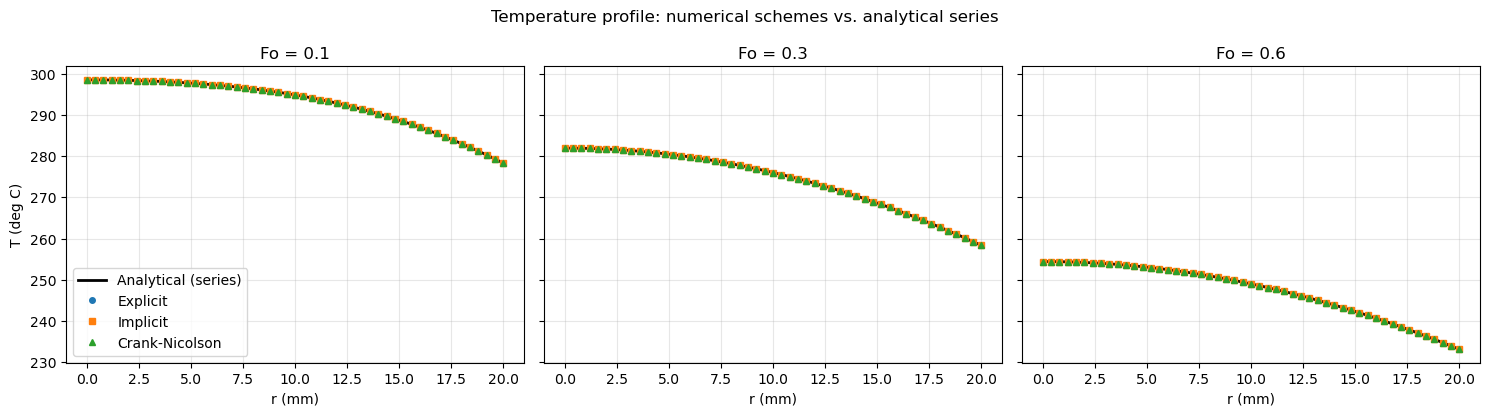

In [100]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2), sharey=True)
r_dense = np.linspace(0, R, 200)

for ax, Fo in zip(axes, Fo_targets):
    t_target = Fo*R**2/alpha
    T_analytical_dense = np.array([theta_ratio_analytical(r, Fo) for r in r_dense])*theta_i + Tinf
    th_e, _ = run_explicit(t_target, dt_common)
    th_i, _ = run_implicit(t_target, dt_common)
    th_c, _ = run_CN(t_target, dt_common)

    ax.plot(r_dense*1000, T_analytical_dense, 'k-', lw=2, label='Analytical (series)')
    ax.plot(r_nodes*1000, th_e+Tinf, 'o', ms=4, label='Explicit')
    ax.plot(r_nodes*1000, th_i+Tinf, 's', ms=4, label='Implicit')
    ax.plot(r_nodes*1000, th_c+Tinf, '^', ms=4, label='Crank-Nicolson')
    ax.set_xlabel('r (mm)')
    ax.set_title(f'Fo = {Fo}')
    ax.grid(alpha=0.3)

axes[0].set_ylabel('T (deg C)')
axes[0].legend()
fig.suptitle('Temperature profile: numerical schemes vs. analytical series')
plt.tight_layout()
plt.show()

# Task (d) — Steps and CPU time for a fixed accuracy target

All three schemes agree with the analytical series to a few thousandths of a kelvin , lift the explicit stability restriction and ask how many time steps (and how much CPU time) each scheme needs to reach the **same** accuracy target of $\Delta t=0.9\Delta t_{\max}$'s error level. The explicit scheme is kept at its stability-limited $\Delta t$ (it cannot be pushed further without going unstable); for the implicit and Crank–Nicolson schemes — which are unconditionally stable — the largest $\Delta t$ that still meets the tolerance is found by bisection.

In [102]:
t_target = 0.6*R**2/alpha
th_a_full = np.array([theta_ratio_analytical(r, 0.6) for r in r_nodes]) * theta_i

tol = 0.01   # K -- fixed engineering accuracy target (comfortably above the
             # baseline errors found for all three schemes in Task (c))

def worst_err(run_func, dt):
    th, steps = run_func(t_target, dt)
    return np.max(np.abs(th - th_a_full)), steps

def max_dt_for_tol(run_func, tol, lo_factor=1.0, hi_factor=2000.0, iters=30):
    lo, hi = lo_factor, hi_factor
    e_lo, _ = worst_err(run_func, dt_common*lo)
    assert e_lo <= tol, "baseline dt already exceeds tolerance"
    for _ in range(iters):
        mid = 0.5*(lo+hi)
        e_mid, _ = worst_err(run_func, dt_common*mid)
        if e_mid <= tol:
            lo = mid
        else:
            hi = mid
    return dt_common*lo

dt_impl_opt = max_dt_for_tol(run_implicit, tol)
dt_cn_opt   = max_dt_for_tol(run_CN, tol)

steps_expl = int(np.ceil(t_target/dt_common))
steps_impl = int(np.ceil(t_target/dt_impl_opt))
steps_cn   = int(np.ceil(t_target/dt_cn_opt))

def time_it(run_func, dt, repeats=5):
    best = np.inf
    for _ in range(repeats):
        t0 = time.perf_counter()
        run_func(t_target, dt)
        t1 = time.perf_counter()
        best = min(best, t1-t0)
    return best

cpu_expl = time_it(run_explicit, dt_common)
cpu_impl = time_it(run_implicit, dt_impl_opt)
cpu_cn   = time_it(run_CN, dt_cn_opt)

summary = pd.DataFrame({
    "scheme": ["Explicit", "Implicit", "Crank-Nicolson"],
    "dt used (s)": [dt_common, dt_impl_opt, dt_cn_opt],
    "steps to Fo=0.6": [steps_expl, steps_impl, steps_cn],
    "CPU time (s)": [cpu_expl, cpu_impl, cpu_cn],
    "max error (K)": [worst_err(run_explicit, dt_common)[0], worst_err(run_implicit, dt_impl_opt)[0], worst_err(run_CN, dt_cn_opt)[0]],
})

display(summary.style.hide(axis='index').format({
    "dt used (s)": '{:.4e}',
    "steps to Fo=0.6": '{:d}',
    "CPU time (s)": '{:.4e}',
    "max error (K)": '{:.5f}',
}).set_caption(f"Steps and CPU time for a fixed accuracy target (max error <= {tol:g} K)"))

scheme,dt used (s),steps to Fo=0.6,CPU time (s),max error (K)
Explicit,3.6000e-03,6667,9.1917e-03,0.00046
Implicit,3.7500e-02,641,3.6454e-03,0.00999
Crank-Nicolson,3.6364e-01,67,5.3420e-04,0.00888


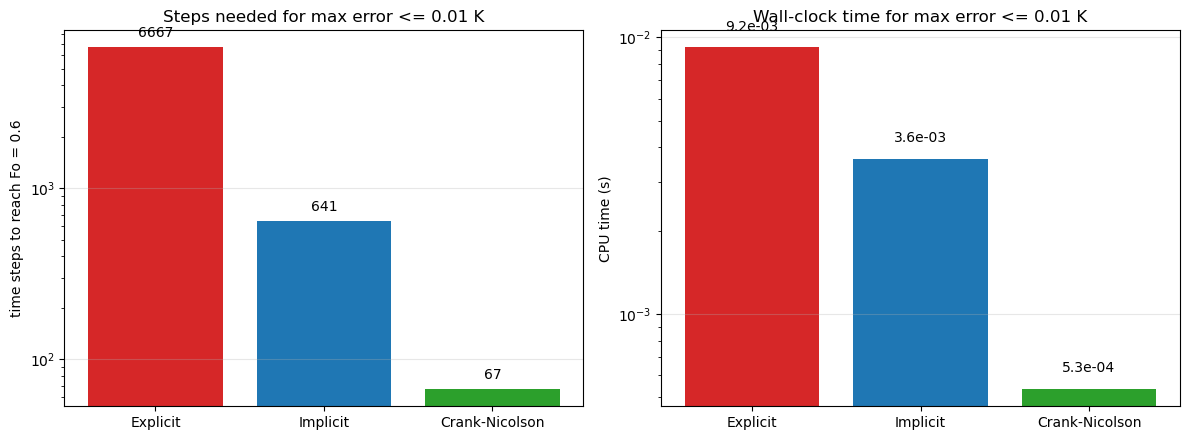

In [104]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
colors = ['#d62728', '#1f77b4', '#2ca02c']

axes[0].bar(summary["scheme"], summary["steps to Fo=0.6"], color=colors)
axes[0].set_ylabel('time steps to reach Fo = 0.6')
axes[0].set_yscale('log')
axes[0].set_title(f'Steps needed for max error <= {tol:g} K')
for i, v in enumerate(summary["steps to Fo=0.6"]):
    axes[0].text(i, v*1.15, str(v), ha='center')
axes[0].grid(alpha=0.3, axis='y')

axes[1].bar(summary["scheme"], summary["CPU time (s)"], color=colors)
axes[1].set_ylabel('CPU time (s)')
axes[1].set_yscale('log')
axes[1].set_title(f'Wall-clock time for max error <= {tol:g} K')
for i, v in enumerate(summary["CPU time (s)"]):
    axes[1].text(i, v*1.15, f'{v:.1e}', ha='center')
axes[1].grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

<h2>Summary and recommendation</h2>
<div style="text-align: justify;">
    <ul>
        <li><strong>(a)</strong> At the centre, \(Fo_{\text{grid}} \le 1/4\) is required for the explicit scheme — twice as restrictive as the interior-node limit \(Fo_{\text{grid}} \le 1/2\) — and this governs the allowable time step over the whole domain.</li>
        <br>
        <li><strong>(b)</strong> All three schemes reduce to the same tridiagonal system \(d\boldsymbol\theta/dFo_{\text{grid}} = A\boldsymbol\theta\); they differ only in how they discretize in time.</li>
        <br>
        <li><strong>(c)</strong> With the same \(\Delta t\) (fixed by the explicit stability limit), all three schemes agree with the analytical solution to within a few thousandths of a kelvin at \(Fo = 0.1, 0.3, 0.6\) and \(r = 0, R/2, R\) — the residual error here is dominated by the \(O(\Delta r^2)\) spatial truncation, not by the choice of time scheme.</li>
        <br>
        <li><strong>(d)</strong> Once the time-step restriction is lifted, Crank–Nicolson reaches the same accuracy target in about \(100\times\) fewer steps than the explicit scheme (and roughly \(10\times\) fewer than the implicit scheme), because its time-truncation error is \(O(\Delta t^2)\) instead of \(O(\Delta t)\). Combined with the fact that the tridiagonal system can be LU-factorised once and reused at every step, Crank–Nicolson is also the fastest in wall-clock time.</li>
        <br>
        <li>For this problem, <strong>Crank–Nicolson</strong> is the best choice — it is unconditionally stable, second-order accurate in time (matching the second-order spatial discretization already in use), and reaches a given accuracy target with far fewer, larger time steps than either the explicit or fully implicit scheme.</li>
    </ul>
</div>

# APPENDIX
CLick the link below to find the source code:  

https://github.com/TarekIssa-98/CFD/blob/main/Assignment2prob3.py
